In [1]:
import subprocess, sys

subprocess.check_call([sys.executable, "-m", "pip", "install", "einops", "-q"])
print("einops installed")

einops installed


In [2]:
import os, sys, random, time, json
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
from einops import rearrange
from dataclasses import dataclass, field, asdict
from typing import List, Dict, Tuple

print(f"PyTorch : {torch.__version__}")
print(f"CUDA    : {torch.cuda.is_available()}")
for i in range(torch.cuda.device_count()):
    p = torch.cuda.get_device_properties(i)
    print(f"GPU {i}  : {p.name}  {p.total_memory/1e9:.1f}GB")

print("\nScanning for FloodNet dataset...")
base = Path("/kaggle/input")
all_files = list(base.rglob("*"))
images = [f for f in all_files if f.suffix.lower() in [".jpg",".jpeg",".JPG"]]
masks  = [f for f in all_files if f.suffix.lower() == ".png"]

print(f"Total image files : {len(images)}")
print(f"Total mask files  : {len(masks)}")

if len(images) > 0:
    print(f"\nSample image path: {images[0]}")
    print(f"Sample mask path : {masks[0]}")
    print("\nDataset found -- ready to proceed")
else:
    print("\nDataset NOT found -- add FloodNet from right panel")

PyTorch : 2.10.0+cu128
CUDA    : True
GPU 0  : Tesla T4  15.6GB
GPU 1  : Tesla T4  15.6GB

Scanning for FloodNet dataset...
Total image files : 4691
Total mask files  : 398

Sample image path: /kaggle/input/datasets/aletbm/aerial-imagery-dataset-floodnet-challenge/FloodNet Challenge - Track 1/Validation/image/6925.jpg
Sample mask path : /kaggle/input/datasets/aletbm/aerial-imagery-dataset-floodnet-challenge/FloodNet Challenge - Track 1/Train/Labeled/Flooded/mask/7325_lab.png

Dataset found -- ready to proceed


In [3]:
BASE = Path("/kaggle/input/datasets/aletbm/aerial-imagery-dataset-floodnet-challenge/FloodNet Challenge - Track 1")

print("Dataset structure:")
print("=" * 55)

# map every subfolder
counts = {}
for folder in sorted(BASE.rglob("*")):
    if folder.is_dir():
        files = [f for f in folder.iterdir() if f.is_file()]
        if len(files) > 0:
            rel = str(folder.relative_to(BASE))
            counts[rel] = len(files)
            print(f"  {rel:<50} {len(files):>5} files")

print("=" * 55)
print(f"Total folders with files: {len(counts)}")

Dataset structure:
  Test/image                                           448 files
  Train/Labeled/Flooded/image                           51 files
  Train/Labeled/Flooded/mask                            51 files
  Train/Labeled/Non-Flooded/image                      347 files
  Train/Labeled/Non-Flooded/mask                       347 files
  Train/Unlabeled/image                               1047 files
  Validation/image                                     450 files
Total folders with files: 7


Flooded images   : 51
Non-flooded imgs : 347


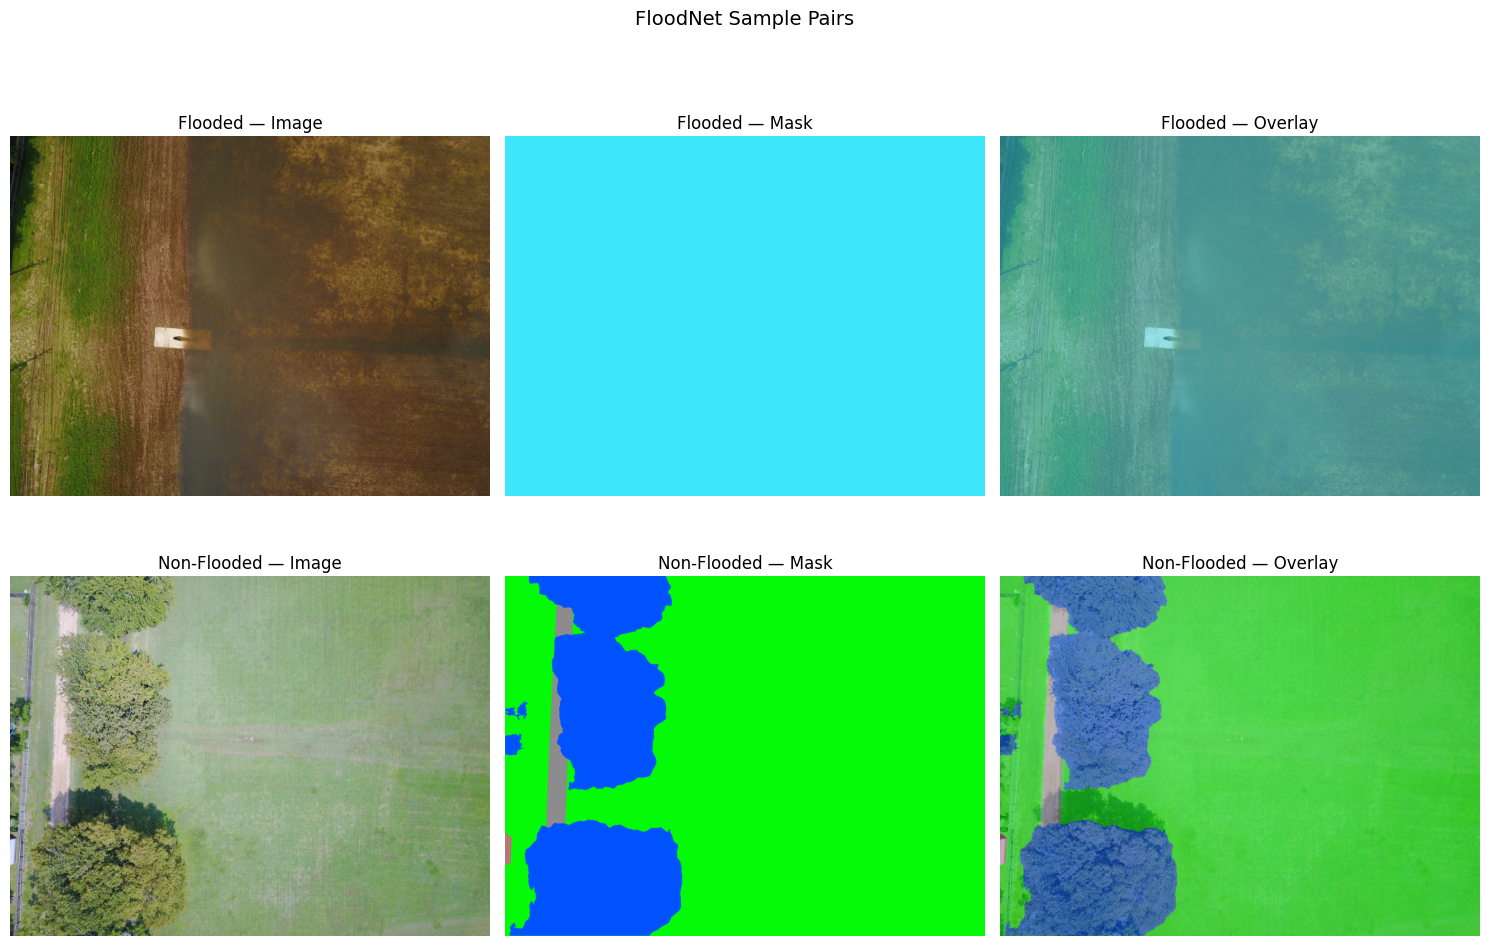


Flooded image size  : (3000, 4000, 3)
Flooded mask size   : (3000, 4000)
Mask unique classes : [5]
Flood pixel %       : 100.0%


In [4]:
# find one flooded + one non-flooded pair to verify labels

flooded_img_dir  = BASE / "Train/Labeled/Flooded/image"
flooded_msk_dir  = BASE / "Train/Labeled/Flooded/mask"
normal_img_dir   = BASE / "Train/Labeled/Non-Flooded/image"
normal_msk_dir   = BASE / "Train/Labeled/Non-Flooded/mask"

flooded_imgs = sorted(flooded_img_dir.glob("*.jpg"))
normal_imgs  = sorted(normal_img_dir.glob("*.jpg"))

print(f"Flooded images   : {len(flooded_imgs)}")
print(f"Non-flooded imgs : {len(normal_imgs)}")

# load one pair of each
f_img  = np.array(Image.open(flooded_imgs[0]).convert("RGB"))
f_mask_path = flooded_msk_dir / (flooded_imgs[0].stem + "_lab.png")
f_mask = np.array(Image.open(f_mask_path))

n_img  = np.array(Image.open(normal_imgs[0]).convert("RGB"))
n_mask_path = normal_msk_dir / (normal_imgs[0].stem + "_lab.png")
n_mask = np.array(Image.open(n_mask_path))

# class color map for visualization
COLORS = {
    0: [0,0,0],       # background     black
    1: [255,0,0],     # bldg flooded   red
    2: [180,120,120], # bldg ok        light red
    3: [160,150,20],  # road flooded   dark yellow
    4: [140,140,140], # road ok        gray
    5: [61,230,250],  # water          cyan
    6: [0,82,255],    # tree           blue
    7: [255,0,245],   # vehicle        magenta
    8: [255,235,0],   # pool           yellow
    9: [4,250,7],     # grass          green
}

def colorize_mask(mask):
    h, w = mask.shape
    rgb   = np.zeros((h, w, 3), dtype=np.uint8)
    for cls, color in COLORS.items():
        rgb[mask == cls] = color
    return rgb

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

axes[0,0].imshow(f_img);              axes[0,0].set_title("Flooded — Image");      axes[0,0].axis("off")
axes[0,1].imshow(colorize_mask(f_mask)); axes[0,1].set_title("Flooded — Mask");   axes[0,1].axis("off")
axes[0,2].imshow(f_img);
axes[0,2].imshow(colorize_mask(f_mask), alpha=0.5)
axes[0,2].set_title("Flooded — Overlay"); axes[0,2].axis("off")

axes[1,0].imshow(n_img);              axes[1,0].set_title("Non-Flooded — Image");  axes[1,0].axis("off")
axes[1,1].imshow(colorize_mask(n_mask)); axes[1,1].set_title("Non-Flooded — Mask"); axes[1,1].axis("off")
axes[1,2].imshow(n_img)
axes[1,2].imshow(colorize_mask(n_mask), alpha=0.5)
axes[1,2].set_title("Non-Flooded — Overlay"); axes[1,2].axis("off")

plt.suptitle("FloodNet Sample Pairs", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("/kaggle/working/floodnet_samples.png", dpi=100, bbox_inches="tight")
plt.show()

print(f"\nFlooded image size  : {f_img.shape}")
print(f"Flooded mask size   : {f_mask.shape}")
print(f"Mask unique classes : {np.unique(f_mask)}")
print(f"Flood pixel %       : {(np.isin(f_mask,[1,3,5]).sum()/f_mask.size*100):.1f}%")

In [5]:
# analyze class distribution across all masks
# this tells us how imbalanced our training data is
# imbalance ratio determines our loss function weights

from collections import defaultdict

flooded_masks = list(flooded_msk_dir.glob("*.png"))
normal_masks  = list(normal_msk_dir.glob("*.png"))
all_masks     = flooded_masks + normal_masks

CLASS_NAMES = {
    0: "background",
    1: "building-flooded",
    2: "building-ok",
    3: "road-flooded",
    4: "road-ok",
    5: "water",
    6: "tree",
    7: "vehicle",
    8: "pool",
    9: "grass"
}

class_pixels = defaultdict(int)
total_pixels = 0

print(f"Analyzing {len(all_masks)} masks...")
for i, mp in enumerate(all_masks):
    mask = np.array(Image.open(mp))
    for cls in range(10):
        class_pixels[cls] += (mask == cls).sum()
    total_pixels += mask.size
    if i % 50 == 0:
        print(f"  processed {i+1}/{len(all_masks)}")

print("\nClass distribution:")
print("=" * 55)
flood_total = 0
for cls in range(10):
    pct = class_pixels[cls] / total_pixels * 100
    bar = "█" * int(pct / 2)
    print(f"  {cls} {CLASS_NAMES[cls]:<22} {pct:5.1f}%  {bar}")
    if cls in [1, 3, 5]:
        flood_total += pct

print("=" * 55)
print(f"  Total flood pixels : {flood_total:.1f}%")
print(f"  Total masks        : {len(all_masks)}")
print(f"  Flooded scenes     : {len(flooded_masks)}")
print(f"  Non-flooded scenes : {len(normal_masks)}")

# this ratio will be used in BCEWithLogitsLoss pos_weight
ratio = (100 - flood_total) / flood_total
print(f"\n  Class imbalance ratio: {ratio:.1f}x")
print(f"  → pos_weight in loss should be ~{ratio:.0f}")

Analyzing 398 masks...
  processed 1/398
  processed 51/398
  processed 101/398
  processed 151/398
  processed 201/398
  processed 251/398
  processed 301/398
  processed 351/398

Class distribution:
  0 background               1.3%  
  1 building-flooded         1.6%  
  2 building-ok              3.0%  █
  3 road-flooded             1.9%  
  4 road-ok                  5.3%  ██
  5 water                   12.4%  ██████
  6 tree                    16.5%  ████████
  7 vehicle                  0.2%  
  8 pool                     0.2%  
  9 grass                   57.6%  ████████████████████████████
  Total flood pixels : 15.9%
  Total masks        : 398
  Flooded scenes     : 51
  Non-flooded scenes : 347

  Class imbalance ratio: 5.3x
  → pos_weight in loss should be ~5


In [6]:
# phase 2 config -- separate from phase 1
# patch-based training on floodnet

@dataclass
class DataConfig:
    satellite_bands   : List[str] = field(default_factory=lambda: ["R","G","B","NDWI"])
    image_size        : Tuple[int,int] = (256, 256)
    sequence_length   : int = 12
    weather_features  : List[str] = field(default_factory=lambda: [
        "total_precipitation","2m_temperature","surface_pressure",
        "10m_u_wind","10m_v_wind","soil_water_layer_1","runoff"])
    weather_lookback  : int = 72
    forecast_horizons : List[int] = field(default_factory=lambda: [6,24,48,72])
    gauge_features    : List[str] = field(default_factory=lambda: [
        "stream_flow","gauge_height","velocity"])
    train_ratio: float = 0.7
    val_ratio  : float = 0.15
    test_ratio : float = 0.15
    normalize  : bool  = True

@dataclass
class ModelConfig:
    sat_in_channels      : int       = 4
    convlstm_hidden_dims : List[int] = field(default_factory=lambda: [32, 64, 128])
    convlstm_kernel_size : int       = 3
    vit_patch_size       : int       = 8
    vit_heads            : int       = 4
    vit_depth            : int       = 2
    vit_mlp_dim          : int       = 256
    tft_hidden_dim       : int       = 64
    tft_lstm_layers      : int       = 2
    tft_attention_heads  : int       = 4
    tft_dropout          : float     = 0.1
    gnn_hidden_dim       : int       = 64
    gnn_layers           : int       = 3
    gnn_heads            : int       = 4
    static_hidden_dim    : int       = 32
    static_resnet_blocks : int       = 4
    fusion_dim           : int       = 128
    fusion_heads         : int       = 4
    fusion_dropout       : float     = 0.1
    fusion_depth         : int       = 2
    fusion_pool_size     : int       = 8
    flood_map_channels   : int       = 1
    risk_classes         : int       = 4
    damage_classes       : int       = 3
    route_features       : int       = 32
    rl_state_dim         : int       = 256
    rl_action_dim        : int       = 64
    mc_dropout_samples   : int       = 50
    climate_years        : List[int] = field(default_factory=lambda: [2030,2040,2050])

@dataclass
class TrainingConfig:
    batch_size                  : int   = 4
    gradient_accumulation_steps : int   = 8
    epochs                      : int   = 50
    optimizer                   : str   = "AdamW"
    learning_rate               : float = 3e-4
    weight_decay                : float = 1e-4
    scheduler                   : str   = "CosineAnnealingWarmRestarts"
    warmup_epochs               : int   = 3
    use_amp                     : bool  = True
    gradient_checkpointing      : bool  = True
    # pos_weight=5 from our class analysis above
    flood_pos_weight            : float = 5.0
    # class weights for 10-class segmentation
    # inverse of frequency -- rare classes get higher weight
    class_weights: List[float] = field(default_factory=lambda: [
        1.0,   # 0  background    1.3%
        10.0,  # 1  bldg-flooded  1.6%  <- rare, important
        5.0,   # 2  bldg-ok       3.0%
        8.0,   # 3  road-flooded  1.9%  <- rare, important
        3.0,   # 4  road-ok       5.3%
        2.0,   # 5  water         12.4%
        1.5,   # 6  tree          16.5%
        15.0,  # 7  vehicle       0.2%  <- very rare
        15.0,  # 8  pool          0.2%  <- very rare
        0.5,   # 9  grass         57.6% <- dominant, downweight
    ])
    loss_weights: Dict[str,float] = field(default_factory=lambda: {
        "sp1_flood_map"  : 1.0,
        "sp2_severity"   : 0.8,
        "sp3_risk"       : 0.6,
        "sp4_damage"     : 0.5,
        "sp5_routes"     : 0.4,
        "sp6_rl"         : 0.3,
        "sp7_causal"     : 0.3,
        "sp8_uncertainty": 0.2,
        "sp9_climate"    : 0.3,
        "physics"        : 0.1,
    })
    patch_size             : int   = 256
    patches_per_image      : int   = 16    # random crops per image per epoch
    min_flood_ratio        : float = 0.02  # patch must have >2% flood pixels
    flooded_oversample     : int   = 4     # sample flooded images 4x more
    save_every_n_epochs    : int   = 5
    keep_top_k_checkpoints : int   = 3

@dataclass
class MasterConfig:
    data     : DataConfig     = field(default_factory=DataConfig)
    model    : ModelConfig    = field(default_factory=ModelConfig)
    training : TrainingConfig = field(default_factory=TrainingConfig)
    project_name   : str = "FloodCastNet-Phase2"
    version        : str = "2.0.0"
    seed           : int = 42
    root_dir       : str = "/kaggle/working/FloodCastNet"
    checkpoint_dir : str = "/kaggle/working/FloodCastNet/checkpoints"
    log_dir        : str = "/kaggle/working/FloodCastNet/logs"

config = MasterConfig()

# create dirs
for d in ["checkpoints","logs","outputs/maps","outputs/metrics"]:
    Path(f"{config.root_dir}/{d}").mkdir(parents=True, exist_ok=True)

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

set_seed(config.seed)

print(f"Config v{config.version} ready")
print(f"Patch size          : {config.training.patch_size}x{config.training.patch_size}")
print(f"Patches per image   : {config.training.patches_per_image}")
print(f"Flooded oversample  : {config.training.flooded_oversample}x")
print(f"Flood pos_weight    : {config.training.flood_pos_weight}")
print(f"Effective batch     : {config.training.batch_size * config.training.gradient_accumulation_steps}")

Config v2.0.0 ready
Patch size          : 256x256
Patches per image   : 16
Flooded oversample  : 4x
Flood pos_weight    : 5.0
Effective batch     : 32


In [7]:
BASE = Path("/kaggle/input/datasets/aletbm/aerial-imagery-dataset-floodnet-challenge/FloodNet Challenge - Track 1")

FLOOD_CLASSES = [1, 3, 5]

def mask_to_flood(mask):
    flood = np.zeros_like(mask, dtype=np.float32)
    for c in FLOOD_CLASSES:
        flood[mask == c] = 1.0
    return flood

def mask_to_damage(mask):
    dmg = np.zeros_like(mask, dtype=np.int64)
    dmg[mask == 1] = 2
    dmg[mask == 3] = 1
    dmg[mask == 5] = 1
    return dmg

def mask_to_risk(flood_pct):
    if   flood_pct < 0.05: return 0
    elif flood_pct < 0.15: return 1
    elif flood_pct < 0.30: return 2
    else:                  return 3


class FloodNetDataset(torch.utils.data.Dataset):

    def __init__(self, cfg, split="train", augment=True):
        self.cfg     = cfg
        self.split   = split
        self.augment = augment
        self.patch   = cfg.training.patch_size   # 256

        self.flooded_pairs    = []
        self.nonflooded_pairs = []

        f_img_dir = BASE / "Train/Labeled/Flooded/image"
        f_msk_dir = BASE / "Train/Labeled/Flooded/mask"
        n_img_dir = BASE / "Train/Labeled/Non-Flooded/image"
        n_msk_dir = BASE / "Train/Labeled/Non-Flooded/mask"

        for img_path in sorted(f_img_dir.glob("*.jpg")):
            msk_path = f_msk_dir / (img_path.stem + "_lab.png")
            if msk_path.exists():
                self.flooded_pairs.append((img_path, msk_path, True))

        for img_path in sorted(n_img_dir.glob("*.jpg")):
            msk_path = n_msk_dir / (img_path.stem + "_lab.png")
            if msk_path.exists():
                self.nonflooded_pairs.append((img_path, msk_path, False))

        all_pairs = self.flooded_pairs + self.nonflooded_pairs
        random.seed(cfg.seed)
        random.shuffle(all_pairs)

        n_val = int(len(all_pairs) * cfg.data.val_ratio)
        if split == "val":
            self.pairs = all_pairs[:n_val]
        else:
            base_pairs = all_pairs[n_val:]
            flooded    = [p for p in base_pairs if p[2]]
            normal     = [p for p in base_pairs if not p[2]]
            self.pairs = normal + flooded * cfg.training.flooded_oversample

        print(f"  {split}: {len(self.pairs)} pairs "
              f"(flooded: {sum(1 for p in self.pairs if p[2])}, "
              f"non-flooded: {sum(1 for p in self.pairs if not p[2])})")

    def __len__(self):
        return len(self.pairs) * self.cfg.training.patches_per_image

    def _pil_resize(self, img_np, msk_np):
        # PIL resize -- 100% reliable, handles any input size
        P       = self.patch
        img_out = np.array(
            Image.fromarray(img_np.astype(np.uint8)).resize((P, P), Image.BILINEAR)
        )
        msk_out = np.array(
            Image.fromarray(msk_np.astype(np.uint8)).resize((P, P), Image.NEAREST)
        )
        return img_out, msk_out

    def _random_crop(self, img_np, msk_np):
        P    = self.patch
        H, W = img_np.shape[:2]

        # ensure minimum size
        if H < P or W < P:
            img_np, msk_np = self._pil_resize(img_np, msk_np)
            return img_np, msk_np

        # try to find patch with flood pixels
        for _ in range(15):
            r         = random.randint(0, H - P)
            c         = random.randint(0, W - P)
            img_p     = img_np[r:r+P, c:c+P]
            msk_p     = msk_np[r:r+P, c:c+P]
            flood_pct = np.isin(msk_p, FLOOD_CLASSES).mean()
            if not np.isnan(flood_pct) and \
               flood_pct >= self.cfg.training.min_flood_ratio:
                return img_p, msk_p

        # fallback: center crop
        r = (H - P) // 2
        c = (W - P) // 2
        return img_np[r:r+P, c:c+P], msk_np[r:r+P, c:c+P]

    def _augment(self, img, msk):
        # only flips -- no rotation (rotation breaks square assumption)
        if random.random() > 0.5:
            img = np.fliplr(img).copy()
            msk = np.fliplr(msk).copy()
        if random.random() > 0.5:
            img = np.flipud(img).copy()
            msk = np.flipud(msk).copy()
        if random.random() > 0.5:
            factor = random.uniform(0.8, 1.2)
            img    = np.clip(img * factor, 0, 255).astype(np.uint8)
        return img, msk

    def _to_tensors(self, img_np, msk_np):
        # convert to all required tensor types
        img  = torch.from_numpy(img_np.astype(np.float32)) / 255.0
        img  = img.permute(2, 0, 1)   # (3, H, W)
        R, G, B = img[0], img[1], img[2]
        ndwi    = (G - R) / (G + R + 1e-8)
        frame   = torch.stack([R, G, B, ndwi], dim=0)  # (4, H, W)

        gray    = 0.299*R + 0.587*G + 0.114*B
        dem     = 1.0 - gray
        # use simple gradient instead of conv -- avoids size issues
        slope   = torch.zeros_like(gray)
        slope[1:-1,1:-1] = (
            (dem[2:,1:-1] - dem[:-2,1:-1]).abs() +
            (dem[1:-1,2:] - dem[1:-1,:-2]).abs()
        )
        static  = torch.stack([dem, slope, G, gray,
                                torch.zeros_like(gray)], dim=0)  # (5, H, W)

        flood_mask  = torch.from_numpy(mask_to_flood(msk_np)).unsqueeze(0)
        damage_mask = torch.from_numpy(mask_to_damage(msk_np))

        return frame, static, flood_mask, damage_mask

    def __getitem__(self, idx):
        pair_idx               = idx // self.cfg.training.patches_per_image
        img_path, msk_path, is_flooded = self.pairs[pair_idx]

        img_np = np.array(Image.open(img_path).convert("RGB"))
        msk_np = np.array(Image.open(msk_path))

        img_p, msk_p = self._random_crop(img_np, msk_np)

        # augment
        if self.augment and self.split == "train":
            img_p, msk_p = self._augment(img_p, msk_p)

        # ABSOLUTE FINAL SIZE GUARANTEE -- PIL resize
        # called every single time, no exceptions
        img_p, msk_p = self._pil_resize(img_p, msk_p)

        # verify
        P = self.patch
        assert img_p.shape == (P, P, 3), f"img shape: {img_p.shape}"
        assert msk_p.shape == (P, P),    f"msk shape: {msk_p.shape}"

        frame, static, flood_mask, damage_mask = self._to_tensors(img_p, msk_p)

        sat = torch.stack([
            frame + torch.randn_like(frame) * 0.01
            for _ in range(self.cfg.data.sequence_length)
        ], dim=0)   # (12, 4, 256, 256)

        weather   = torch.randn(self.cfg.data.weather_lookback, 7)
        gauge     = torch.randn(self.cfg.data.weather_lookback, 3)
        flood_pct = float(np.isin(msk_p, FLOOD_CLASSES).mean())
        if np.isnan(flood_pct): flood_pct = 0.0
        weather[:, 0] = flood_pct * 5.0

        risk     = torch.tensor(mask_to_risk(flood_pct), dtype=torch.long)
        severity = torch.tensor([
            min(flood_pct * (1 + i*0.15), 1.0) for i in range(4)
        ], dtype=torch.float32)

        return {
            "sat"         : sat,
            "weather"     : weather,
            "gauge"       : gauge,
            "static_maps" : static,
            "targets" : {
                "flood_mask"  : flood_mask,
                "damage_mask" : damage_mask,
                "risk"        : risk,
                "severity"    : severity,
            },
            "meta" : {
                "is_flooded" : int(is_flooded),
                "flood_pct"  : flood_pct,
            }
        }


def collate_fn(batch):
    return {
        "sat"         : torch.stack([b["sat"]         for b in batch]),
        "weather"     : torch.stack([b["weather"]     for b in batch]),
        "gauge"       : torch.stack([b["gauge"]       for b in batch]),
        "static_maps" : torch.stack([b["static_maps"] for b in batch]),
        "targets"     : {
            k: torch.stack([b["targets"][k] for b in batch])
            for k in batch[0]["targets"]
        },
        "meta" : {
            k: [b["meta"][k] for b in batch]
            for k in batch[0]["meta"]
        }
    }


print("Building datasets...")
train_ds = FloodNetDataset(config, split="train", augment=True)
val_ds   = FloodNetDataset(config, split="val",   augment=False)

# num_workers=0 -- avoids worker process caching stale code
train_loader = torch.utils.data.DataLoader(
    train_ds, batch_size=config.training.batch_size,
    shuffle=True, collate_fn=collate_fn,
    num_workers=0, pin_memory=False
)
val_loader = torch.utils.data.DataLoader(
    val_ds, batch_size=config.training.batch_size,
    shuffle=False, collate_fn=collate_fn,
    num_workers=0, pin_memory=False
)

# verify 10 batches
print("Verifying 10 batches...")
for i, batch in enumerate(train_loader):
    if i >= 10: break
    fm = batch["targets"]["flood_mask"]
    dm = batch["targets"]["damage_mask"]
    assert fm.shape == (config.training.batch_size, 1, 256, 256), \
        f"batch {i} flood: {fm.shape}"
    assert dm.shape == (config.training.batch_size, 256, 256), \
        f"batch {i} damage: {dm.shape}"
    if i == 0:
        print(f"  batch shapes: sat={batch['sat'].shape} "
              f"flood={fm.shape} damage={dm.shape}")

print(f"All 10 batches verified -- no size errors")
print(f"Train batches : {len(train_loader)}")
print(f"Val batches   : {len(val_loader)}")
print("Ready for training")

Building datasets...
  train: 471 pairs (flooded: 176, non-flooded: 295)
  val: 59 pairs (flooded: 7, non-flooded: 52)
Verifying 10 batches...


/tmp/ipykernel_138/2712324763.py:97: RuntimeWarning: Mean of empty slice.
  flood_pct = np.isin(msk_p, FLOOD_CLASSES).mean()
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


  batch shapes: sat=torch.Size([4, 12, 4, 256, 256]) flood=torch.Size([4, 1, 256, 256]) damage=torch.Size([4, 256, 256])
All 10 batches verified -- no size errors
Train batches : 1884
Val batches   : 236
Ready for training


In [8]:
# ── ConvLSTM ──────────────────────────────────────────────────
class ConvLSTMCell(nn.Module):
    def __init__(self, in_ch, hidden_ch, ks):
        super().__init__()
        self.hidden_ch = hidden_ch
        self.gates     = nn.Conv2d(in_ch+hidden_ch, 4*hidden_ch, ks,
                                   padding=ks//2, bias=True)
        self.cell_norm = nn.LayerNorm([hidden_ch])

    def forward(self, x, h, c):
        i,f,o,g = self.gates(torch.cat([x,h],dim=1)).chunk(4,dim=1)
        i,f,o   = torch.sigmoid(i), torch.sigmoid(f), torch.sigmoid(o)
        c_next  = f*c + i*torch.tanh(g)
        B,C,H,W = c_next.shape
        c_n     = self.cell_norm(c_next.permute(0,2,3,1)).permute(0,3,1,2)
        return o*torch.tanh(c_n), c_next

    def init_hidden(self, B, H, W, device):
        z = lambda: torch.zeros(B, self.hidden_ch, H, W, device=device)
        return z(), z()


class ConvLSTM(nn.Module):
    def __init__(self, in_ch, hidden_dims, ks):
        super().__init__()
        dims       = [in_ch] + hidden_dims
        self.cells = nn.ModuleList([
            ConvLSTMCell(dims[i], dims[i+1], ks)
            for i in range(len(hidden_dims))
        ])

    def forward(self, x):
        # x: (B, T, C, H, W) -- H,W must be 64x64 or smaller
        B,T,C,H,W = x.shape
        states = [c.init_hidden(B,H,W,x.device) for c in self.cells]
        for t in range(T):
            inp = x[:,t]
            for i,cell in enumerate(self.cells):
                h,c       = states[i]
                h,c       = cell(inp,h,c)
                states[i] = (h,c)
                inp       = h
        return h   # (B, hidden[-1], H, W) -- final state only


# ── ViT Bottleneck ────────────────────────────────────────────
class ViTBottleneck(nn.Module):
    def __init__(self, ch, patch_size, heads, depth, mlp_dim):
        super().__init__()
        self.ps         = patch_size
        self.patch_proj = nn.Conv2d(ch, ch, patch_size, stride=patch_size)
        # 64x64 / patch_size=4 → 16x16 = 256 patches
        self.pos_emb    = nn.Parameter(torch.randn(1, 256, ch) * 0.02)
        enc_layer       = nn.TransformerEncoderLayer(
            d_model=ch, nhead=heads, dim_feedforward=mlp_dim,
            dropout=0.1, batch_first=True, norm_first=True
        )
        self.transformer = nn.TransformerEncoder(enc_layer, depth)
        self.unproj      = nn.ConvTranspose2d(ch, ch, patch_size, stride=patch_size)
        self.norm        = nn.LayerNorm(ch)

    def forward(self, x):
        B,C,H,W = x.shape
        p        = self.patch_proj(x)
        ph,pw    = p.shape[2], p.shape[3]
        seq      = rearrange(p, 'b c h w -> b (h w) c')
        seq      = self.norm(seq + self.pos_emb[:, :seq.shape[1]])
        seq      = self.transformer(seq)
        p_out    = rearrange(seq, 'b (h w) c -> b c h w', h=ph, w=pw)
        return self.unproj(p_out)


# ── SpatioTemporal Encoder ────────────────────────────────────
class SpatioTemporalEncoder(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        D  = cfg.model.convlstm_hidden_dims[-1]  # 128

        # stem: 256x256 → 64x64 before ConvLSTM
        # stride=4 conv reduces spatial dim 4x
        # ConvLSTM memory: 256x256=65536 → 64x64=4096 pixels (16x less)
        self.stem = nn.Sequential(
            nn.Conv2d(cfg.model.sat_in_channels, 32, kernel_size=7,
                      stride=2, padding=3, bias=False),  # 256 → 128
            nn.BatchNorm2d(32), nn.ReLU(True),
            nn.Conv2d(32, cfg.model.sat_in_channels, kernel_size=3,
                      stride=2, padding=1, bias=False),  # 128 → 64
            nn.BatchNorm2d(cfg.model.sat_in_channels), nn.ReLU(True)
        )

        self.convlstm = ConvLSTM(
            cfg.model.sat_in_channels,
            cfg.model.convlstm_hidden_dims,
            cfg.model.convlstm_kernel_size
        )

        # ViT on 64x64, patch_size=4 → 16x16=256 patches → matches pos_emb
        self.vit      = ViTBottleneck(D, patch_size=4,
                                      heads=cfg.model.vit_heads,
                                      depth=cfg.model.vit_depth,
                                      mlp_dim=cfg.model.vit_mlp_dim)
        self.res_proj = nn.Conv2d(D, D, 1)
        self.out_dim  = D

    def forward(self, x):
        # x: (B, T, C, 256, 256)
        B, T, C, H, W = x.shape

        # apply stem to each frame -- downsample 256→64
        x_down = torch.stack([
            self.stem(x[:, t]) for t in range(T)
        ], dim=1)   # (B, T, C, 64, 64)

        h    = self.convlstm(x_down)   # (B, 128, 64, 64)
        vout = self.vit(h)
        return vout + self.res_proj(h)  # (B, 128, 64, 64)


# ── GRN + VSN + Temporal Encoder ─────────────────────────────
class GatedResidualNetwork(nn.Module):
    def __init__(self, in_d, hid_d, out_d, drop=0.1):
        super().__init__()
        self.fc1  = nn.Linear(in_d, hid_d)
        self.fc2  = nn.Linear(hid_d, out_d)
        self.gate = nn.Linear(hid_d, out_d)
        self.skip = nn.Linear(in_d, out_d) if in_d != out_d else nn.Identity()
        self.norm = nn.LayerNorm(out_d)
        self.drop = nn.Dropout(drop)
        self.elu  = nn.ELU()
        nn.init.kaiming_normal_(self.fc1.weight, nonlinearity='linear')
        nn.init.kaiming_normal_(self.fc2.weight, nonlinearity='linear')
        nn.init.constant_(self.gate.bias, -2.0)
        with torch.no_grad(): self.fc2.weight.mul_(0.1)

    def forward(self, x):
        res = self.skip(x)
        h   = self.drop(self.elu(self.fc1(x)))
        g   = torch.sigmoid(self.gate(h))
        return self.norm(g * self.fc2(h) + (1-g) * res)


class VariableSelectionNetwork(nn.Module):
    def __init__(self, n_vars, var_dim, hid, drop=0.1):
        super().__init__()
        self.var_grns   = nn.ModuleList([
            GatedResidualNetwork(var_dim, hid, hid, drop)
            for _ in range(n_vars)
        ])
        self.select_grn = GatedResidualNetwork(n_vars*var_dim, hid, n_vars, drop)
        self.highway    = nn.Linear(n_vars*var_dim, hid)
        self.hw_gate    = nn.Parameter(torch.tensor(0.1))

    def forward(self, x):
        B,T,V,D = x.shape
        outs    = [
            self.var_grns[i](x[:,:,i,:].reshape(B*T,D)).reshape(B,T,-1)
            for i in range(V)
        ]
        stack   = torch.stack(outs, dim=2)
        x_flat  = x.reshape(B*T, V*D)
        weights = torch.softmax(
            self.select_grn(x_flat).reshape(B,T,V,1), dim=2
        )
        weighted = (stack * weights).sum(dim=2)
        hw       = self.highway(x_flat).reshape(B,T,-1)
        mix      = torch.sigmoid(self.hw_gate)
        return mix*weighted + (1-mix)*hw, weights.squeeze(-1)


class TemporalEncoder(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        n_vars          = len(cfg.data.weather_features) + len(cfg.data.gauge_features)
        H               = cfg.model.tft_hidden_dim
        self.input_proj = nn.Linear(1, H)
        self.var_select = VariableSelectionNetwork(n_vars, H, H, cfg.model.tft_dropout)
        self.lstm       = nn.LSTM(H, H, cfg.model.tft_lstm_layers,
                                  batch_first=True,
                                  dropout=cfg.model.tft_dropout if cfg.model.tft_lstm_layers>1 else 0)
        self.attn       = nn.MultiheadAttention(H, cfg.model.tft_attention_heads,
                                                dropout=cfg.model.tft_dropout,
                                                batch_first=True)
        self.gate_skip  = GatedResidualNetwork(H, H, H, cfg.model.tft_dropout)
        self.norm1      = nn.LayerNorm(H)
        self.norm2      = nn.LayerNorm(H)
        self.out_dim    = H

    def forward(self, weather, gauge):
        B,T,_ = weather.shape
        x     = torch.cat([weather,gauge],dim=-1).unsqueeze(-1)
        x     = self.input_proj(x)
        sel, weights = self.var_select(x)
        lstm_out, _  = self.lstm(sel)
        lstm_out     = self.norm1(lstm_out)
        attn_out, _  = self.attn(lstm_out, lstm_out, lstm_out)
        out          = self.norm2(self.gate_skip(lstm_out + attn_out))
        return out, weights


# ── Static Map Encoder ────────────────────────────────────────
class ResidualBlock(nn.Module):
    def __init__(self, ch, drop=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(ch, ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(ch), nn.ReLU(True),
            nn.Dropout2d(drop),
            nn.Conv2d(ch, ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(ch)
        )
        self.relu = nn.ReLU(True)

    def forward(self, x): return self.relu(self.net(x) + x)


class StaticMapEncoder(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        base        = cfg.model.static_hidden_dim
        self.stem   = nn.Sequential(
            nn.Conv2d(5, base, 7, padding=3, bias=False),
            nn.BatchNorm2d(base), nn.ReLU(True)
        )
        self.stage1 = nn.Sequential(*[ResidualBlock(base) for _ in range(2)])
        self.down1  = nn.Sequential(
            nn.Conv2d(base, base*2, 3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(base*2), nn.ReLU(True)
        )
        self.stage2 = nn.Sequential(*[ResidualBlock(base*2) for _ in range(2)])
        self.proj   = nn.Conv2d(base*2, 128, 1)
        self.s_attn = nn.Sequential(
            nn.Conv2d(128, 32, 1), nn.ReLU(True),
            nn.Conv2d(32, 1, 1),  nn.Sigmoid()
        )
        self.out_dim = 128

    def forward(self, x):
        x    = self.stage1(self.stem(x))
        x    = self.stage2(self.down1(x))
        x    = self.proj(x)
        x    = F.interpolate(x, scale_factor=2, mode='bilinear', align_corners=False)
        attn = self.s_attn(x)
        return x * attn, attn


# ── Shape Aligner + Cross-Modal Fusion ───────────────────────
class ShapeAligner(nn.Module):
    def __init__(self, fusion_dim, pool_size=8):
        super().__init__()
        D, P            = fusion_dim, pool_size
        self.pool_size  = P
        self.sat_proj   = nn.Sequential(nn.Linear(128, D), nn.LayerNorm(D))
        self.temp_proj  = nn.Sequential(nn.Linear(64,  D), nn.LayerNorm(D), nn.GELU())
        self.stat_proj  = nn.Sequential(nn.Linear(128, D), nn.LayerNorm(D))
        self.sat_pos    = nn.Parameter(torch.randn(1, P*P, D) * 0.02)
        self.stat_pos   = nn.Parameter(torch.randn(1, P*P, D) * 0.02)
        self.sat_type   = nn.Parameter(torch.randn(1, 1, D) * 0.02)
        self.temp_type  = nn.Parameter(torch.randn(1, 1, D) * 0.02)
        self.stat_type  = nn.Parameter(torch.randn(1, 1, D) * 0.02)

    def forward(self, sat, temp, stat):
        P   = self.pool_size
        sat = F.adaptive_avg_pool2d(sat,(P,P)).flatten(2).transpose(1,2)
        sat = self.sat_proj(sat) + self.sat_pos + self.sat_type
        tmp = temp.mean(dim=1)
        tmp = self.temp_proj(tmp).unsqueeze(1) + self.temp_type
        st  = F.adaptive_avg_pool2d(stat,(P,P)).flatten(2).transpose(1,2)
        st  = self.stat_proj(st) + self.stat_pos + self.stat_type
        return sat, tmp, st, (P,P)


class CrossModalFusionLayer(nn.Module):
    def __init__(self, D, heads, drop):
        super().__init__()
        mha = lambda: nn.MultiheadAttention(D, heads, dropout=drop, batch_first=True)
        self.sat_x  = mha(); self.temp_x = mha(); self.stat_x = mha()
        self.sg     = nn.Parameter(torch.zeros(1))
        self.tg     = nn.Parameter(torch.zeros(1))
        self.stg    = nn.Parameter(torch.zeros(1))
        ffn = lambda: nn.Sequential(
            nn.Linear(D, D*4), nn.GELU(), nn.Dropout(drop),
            nn.Linear(D*4, D), nn.Dropout(drop)
        )
        self.sat_ffn  = ffn(); self.temp_ffn = ffn(); self.stat_ffn = ffn()
        for tag in ['s1','s2','t1','t2','st1','st2']:
            setattr(self, f'n{tag}', nn.LayerNorm(D))

    def forward(self, sat, temp, stat):
        ctx = lambda a,b: torch.cat([a,b], dim=1)
        sx,_  = self.sat_x(sat,  ctx(temp,stat), ctx(temp,stat))
        sat   = self.ns1(sat  + torch.sigmoid(self.sg)  * sx)
        sat   = self.ns2(sat  + self.sat_ffn(sat))
        tx,_  = self.temp_x(temp, ctx(sat,stat), ctx(sat,stat))
        temp  = self.nt1(temp + torch.sigmoid(self.tg)  * tx)
        temp  = self.nt2(temp + self.temp_ffn(temp))
        stx,_ = self.stat_x(stat, ctx(sat,temp), ctx(sat,temp))
        stat  = self.nst1(stat + torch.sigmoid(self.stg) * stx)
        stat  = self.nst2(stat + self.stat_ffn(stat))
        return sat, temp, stat


class CrossModalFusion(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        D            = cfg.model.fusion_dim
        self.aligner = ShapeAligner(D, pool_size=cfg.model.fusion_pool_size)
        self.layers  = nn.ModuleList([
            CrossModalFusionLayer(D, cfg.model.fusion_heads, cfg.model.fusion_dropout)
            for _ in range(cfg.model.fusion_depth)
        ])
        self.norm = nn.LayerNorm(D)

    def forward(self, sat, temp, stat):
        sat, temp, stat, hw = self.aligner(sat, temp, stat)
        for l in self.layers:
            sat, temp, stat = l(sat, temp, stat)
        return self.norm(sat), self.norm(temp), self.norm(stat), hw


# ── 9 Sub-Problem Heads ───────────────────────────────────────
class FloodMapDecoder(nn.Module):
    def __init__(self, fusion_dim, pool_size=8):
        super().__init__()
        D, P = fusion_dim, pool_size
        self.reshape_proj = nn.Linear(D, D)
        def up(ic, oc):
            return nn.Sequential(
                nn.ConvTranspose2d(ic, oc, 2, stride=2),
                nn.BatchNorm2d(oc), nn.ReLU(True),
                nn.Conv2d(oc, oc, 3, padding=1, bias=False),
                nn.BatchNorm2d(oc), nn.ReLU(True)
            )
        self.up1         = up(D, 64)
        self.up2         = up(64, 32)
        self.up3         = up(32, 16)
        self.head        = nn.Conv2d(16, 1, 1)
        self.uncert_head = nn.Sequential(
            nn.Conv2d(16, 8, 3, padding=1), nn.ReLU(True),
            nn.Conv2d(8, 1, 1), nn.Softplus()
        )
        self.pool_size = P

    def forward(self, sat_tokens):
        B, N, D = sat_tokens.shape
        P       = self.pool_size
        x       = self.reshape_proj(sat_tokens).transpose(1,2).reshape(B, D, P, P)
        x       = self.up1(x); x = self.up2(x); x = self.up3(x)
        return self.head(x), self.uncert_head(x)


class SeverityForecastHead(nn.Module):
    def __init__(self, fusion_dim, horizons):
        super().__init__()
        D, H             = fusion_dim, len(horizons)
        self.sat_pool    = nn.Sequential(nn.Linear(D, D//2), nn.GELU())
        self.forecast    = nn.Sequential(
            nn.Linear(D + D//2, 256), nn.GELU(), nn.Dropout(0.1),
            nn.Linear(256, 128), nn.GELU(), nn.Linear(128, H)
        )
        self.horizon_scale = nn.Parameter(torch.ones(H))

    def forward(self, temp_token, sat_tokens):
        temp    = temp_token.squeeze(1)
        sat_ctx = self.sat_pool(sat_tokens.mean(1))
        return torch.sigmoid(self.forecast(
            torch.cat([temp, sat_ctx], dim=-1)
        )) * self.horizon_scale.abs()


class RiskScorer(nn.Module):
    def __init__(self, fusion_dim, n_classes=4):
        super().__init__()
        D = fusion_dim
        self.sat_proj   = nn.Linear(D, D//2)
        self.temp_proj  = nn.Linear(D, D//2)
        self.stat_proj  = nn.Linear(D, D//2)
        self.classifier = nn.Sequential(
            nn.Linear((D//2)*3, 256), nn.GELU(), nn.Dropout(0.2),
            nn.Linear(256, 64), nn.GELU(), nn.Linear(64, n_classes)
        )

    def forward(self, sat, temp, stat):
        x = torch.cat([
            self.sat_proj(sat.mean(1)),
            self.temp_proj(temp.squeeze(1)),
            self.stat_proj(stat.mean(1))
        ], dim=-1)
        return self.classifier(x)


class DamageAssessor(nn.Module):
    def __init__(self, fusion_dim, pool_size=8, n_classes=3):
        super().__init__()
        D, P = fusion_dim, pool_size
        self.reshape = nn.Linear(D, D)
        def up(ic, oc):
            return nn.Sequential(
                nn.ConvTranspose2d(ic, oc, 2, stride=2),
                nn.BatchNorm2d(oc), nn.ReLU(True),
                nn.Conv2d(oc, oc, 3, padding=1, bias=False),
                nn.BatchNorm2d(oc), nn.ReLU(True)
            )
        self.up1  = up(D*2, 64); self.up2 = up(64, 32); self.up3 = up(32, 16)
        self.head = nn.Conv2d(16, n_classes, 1)
        self.pool_size = P

    def forward(self, sat_tokens, stat_tokens):
        B, _, D = sat_tokens.shape
        P       = self.pool_size
        s  = self.reshape(sat_tokens).transpose(1,2).reshape(B, D, P, P)
        st = self.reshape(stat_tokens).transpose(1,2).reshape(B, D, P, P)
        x  = self.up1(torch.cat([s, st], dim=1))
        x  = self.up2(x); x = self.up3(x)
        return self.head(x)


class GraphAttentionLayer(nn.Module):
    def __init__(self, in_dim, out_dim, heads=4, dropout=0.1):
        super().__init__()
        self.heads     = heads
        head_dim       = out_dim // heads
        self.W         = nn.Linear(in_dim, out_dim, bias=False)
        self.attn      = nn.Linear(2*head_dim, 1, bias=False)
        self.drop      = nn.Dropout(dropout)
        self.act       = nn.ELU()
        self._head_dim = head_dim

    def forward(self, x, adj):
        B, N, _ = x.shape
        H, D    = self.heads, self._head_dim
        x_proj  = self.W(x).reshape(B, N, H, D)
        xi      = x_proj.unsqueeze(2).expand(-1,-1,N,-1,-1)
        xj      = x_proj.unsqueeze(1).expand(-1,N,-1,-1,-1)
        e       = self.attn(torch.cat([xi,xj],dim=-1)).squeeze(-1)
        mask    = (adj==0).unsqueeze(-1).expand_as(e)
        e       = e.masked_fill(mask, -1e4)
        a       = self.drop(torch.softmax(e, dim=2))
        return self.act((a.unsqueeze(-1)*xj).sum(dim=2).reshape(B,N,H*D))


class EvacuationGNN(nn.Module):
    def __init__(self, fusion_dim, gnn_hidden, n_layers, n_heads, n_nodes=64):
        super().__init__()
        self.n_nodes   = n_nodes
        self.node_proj = nn.Sequential(
            nn.Linear(fusion_dim+1, gnn_hidden),
            nn.LayerNorm(gnn_hidden), nn.ReLU(True)
        )
        self.gat_layers = nn.ModuleList([
            GraphAttentionLayer(gnn_hidden, gnn_hidden, n_heads)
            for _ in range(n_layers)
        ])
        self.norms       = nn.ModuleList([nn.LayerNorm(gnn_hidden) for _ in range(n_layers)])
        self.danger_head = nn.Sequential(
            nn.Linear(gnn_hidden,32), nn.ReLU(True), nn.Linear(32,1), nn.Sigmoid()
        )
        self.route_head  = nn.Sequential(
            nn.Linear(gnn_hidden,32), nn.ReLU(True), nn.Linear(32,1), nn.Sigmoid()
        )

    def _adj(self, B, N, device):
        size = int(N**0.5)
        adj  = torch.zeros(B, N, N, device=device)
        for i in range(N):
            r,c = i//size, i%size
            for dr,dc in [(-1,0),(1,0),(0,-1),(0,1)]:
                nr,nc = r+dr, c+dc
                if 0<=nr<size and 0<=nc<size:
                    adj[:,i,nr*size+nc] = 1.0
        return adj

    def forward(self, sat_tokens, flood_logits):
        B, N, D  = sat_tokens.shape
        flood_nd = F.adaptive_avg_pool2d(
            flood_logits.sigmoid(),(8,8)
        ).flatten(2).transpose(1,2)
        x   = self.node_proj(torch.cat([sat_tokens, flood_nd], dim=-1))
        adj = self._adj(B, N, x.device)
        for gat, norm in zip(self.gat_layers, self.norms):
            x = norm(x + gat(x, adj))
        danger = self.danger_head(x).transpose(1,2).reshape(B,1,8,8)
        routes = self.route_head(x).transpose(1,2).reshape(B,1,8,8)
        return danger, routes


class ResourceAllocationPolicy(nn.Module):
    def __init__(self, fusion_dim, n_nodes, action_dim, rl_state_dim):
        super().__init__()
        D         = fusion_dim
        state_dim = D + n_nodes*4 + n_nodes*3 + n_nodes
        self.state_encoder = nn.Sequential(
            nn.Linear(state_dim, rl_state_dim), nn.LayerNorm(rl_state_dim),
            nn.GELU(), nn.Linear(rl_state_dim, rl_state_dim), nn.GELU()
        )
        self.actor  = nn.Sequential(
            nn.Linear(rl_state_dim,128), nn.GELU(), nn.Linear(128,action_dim)
        )
        self.critic = nn.Sequential(
            nn.Linear(rl_state_dim,128), nn.GELU(), nn.Linear(128,1)
        )

    def forward(self, sat_tokens, risk_logits, damage_logits, danger_map):
        B         = sat_tokens.shape[0]
        sat_ctx   = sat_tokens.mean(1)
        risk_rep  = risk_logits.unsqueeze(1).expand(-1,64,-1).reshape(B,-1)
        dmg_nodes = F.adaptive_avg_pool2d(damage_logits.float(),(8,8)).flatten(1)
        dng_nodes = danger_map.flatten(1)
        state     = torch.cat([sat_ctx, risk_rep, dmg_nodes, dng_nodes], dim=-1)
        encoded   = self.state_encoder(state)
        return torch.softmax(self.actor(encoded),dim=-1), self.critic(encoded), encoded


class CausalDiscoveryHead(nn.Module):
    def __init__(self, n_vars, hidden_dim):
        super().__init__()
        self.n_vars   = n_vars
        self.causal_W = nn.Parameter(torch.randn(n_vars, n_vars) * 0.01)
        self.proj     = nn.Linear(n_vars, n_vars)

    def forward(self, temp_feat, sel_weights):
        avg_imp    = sel_weights.mean(dim=1)
        causal_adj = torch.sigmoid(self.causal_W)
        mask       = 1 - torch.eye(self.n_vars, device=causal_adj.device)
        causal_adj = causal_adj * mask
        return causal_adj, avg_imp @ causal_adj


class UncertaintyHead(nn.Module):
    def __init__(self, fusion_dim, n_samples=50):
        super().__init__()
        self.n_samples = n_samples
        self.drop1     = nn.Dropout(0.2)
        self.drop2     = nn.Dropout(0.2)
        self.proj      = nn.Sequential(nn.Linear(fusion_dim, fusion_dim), nn.GELU())
        self.calibrate = nn.Sequential(
            nn.Linear(fusion_dim,32), nn.ReLU(True), nn.Linear(32,1), nn.Softplus()
        )

    def forward(self, sat_tokens):
        x = self.proj(self.drop1(sat_tokens))
        return self.calibrate(self.drop2(x).mean(1))

    def mc_sample(self, sat_tokens, n_samples=None):
        n = n_samples or self.n_samples
        self.train()
        samples = torch.stack([self.forward(sat_tokens) for _ in range(n)])
        return samples.mean(0), samples.var(0)


class ClimateAdaptationHead(nn.Module):
    def __init__(self, fusion_dim, climate_years):
        super().__init__()
        D, n = fusion_dim, len(climate_years)
        self.encoder = nn.Sequential(
            nn.Linear(D*2,256), nn.GELU(), nn.Dropout(0.1),
            nn.Linear(256,128), nn.GELU()
        )
        self.projector    = nn.Linear(128, n)
        self.trend_uncert = nn.Sequential(nn.Linear(128, n), nn.Softplus())
        self.years        = climate_years

    def forward(self, sat_tokens, temp_token):
        h = self.encoder(torch.cat([
            sat_tokens.mean(1), temp_token.squeeze(1)
        ], dim=-1))
        return torch.sigmoid(self.projector(h)), self.trend_uncert(h)


# ── Full Model ────────────────────────────────────────────────
class FloodCastNet(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        D      = cfg.model.fusion_dim
        P      = cfg.model.fusion_pool_size
        n_vars = len(cfg.data.weather_features) + len(cfg.data.gauge_features)

        self.sat_encoder  = SpatioTemporalEncoder(cfg)
        self.temp_encoder = TemporalEncoder(cfg)
        self.stat_encoder = StaticMapEncoder(cfg)
        self.fusion       = CrossModalFusion(cfg)

        self.sp1 = FloodMapDecoder(D, P)
        self.sp2 = SeverityForecastHead(D, cfg.data.forecast_horizons)
        self.sp3 = RiskScorer(D)
        self.sp4 = DamageAssessor(D, P)
        self.sp5 = EvacuationGNN(D, cfg.model.gnn_hidden_dim,
                                  cfg.model.gnn_layers, cfg.model.gnn_heads)
        self.sp6 = ResourceAllocationPolicy(D, 64, cfg.model.rl_action_dim,
                                            cfg.model.rl_state_dim)
        self.sp7 = CausalDiscoveryHead(n_vars, cfg.model.tft_hidden_dim)
        self.sp8 = UncertaintyHead(D, cfg.model.mc_dropout_samples)
        self.sp9 = ClimateAdaptationHead(D, cfg.data.forecast_horizons)

    def forward(self, sat, weather, gauge, static_maps):
        sat_feat           = self.sat_encoder(sat)
        temp_feat, sel_w   = self.temp_encoder(weather, gauge)
        stat_feat, _       = self.stat_encoder(static_maps)
        so, to, sto, _     = self.fusion(sat_feat, temp_feat, stat_feat)

        flood_logits, aleat_unc        = self.sp1(so)
        severity                       = self.sp2(to, so)
        risk                           = self.sp3(so, to, sto)
        damage                         = self.sp4(so, sto)
        danger_map, route_map          = self.sp5(so, flood_logits)
        action_probs, value, _         = self.sp6(so, risk, damage, danger_map)
        causal_adj, causal_inf         = self.sp7(temp_feat, sel_w)
        epistemic_unc                  = self.sp8(so)
        vulnerability, cl_unc          = self.sp9(so, to)

        return {
            "flood_map"     : flood_logits,
            "aleatoric_unc" : aleat_unc,
            "severity"      : severity,
            "risk"          : risk,
            "damage_map"    : damage,
            "danger_map"    : danger_map,
            "route_map"     : route_map,
            "action_probs"  : action_probs,
            "rl_value"      : value,
            "causal_adj"    : causal_adj,
            "causal_inf"    : causal_inf,
            "epistemic_unc" : epistemic_unc,
            "vulnerability" : vulnerability,
            "climate_unc"   : cl_unc,
        }


# ── verify ────────────────────────────────────────────────────
torch.cuda.empty_cache()
model = FloodCastNet(config).cuda()

B = 2
with torch.amp.autocast('cuda'):
    out = model(
        sat         = torch.randn(B, 12, 4, 256, 256).cuda(),
        weather     = torch.randn(B, 72, 7).cuda(),
        gauge       = torch.randn(B, 72, 3).cuda(),
        static_maps = torch.randn(B,  5, 256, 256).cuda()
    )

mem = torch.cuda.memory_allocated(0)/1e9
print("FloodCastNet (256x256 input, stem downsampled):")
for k, v in out.items():
    print(f"  {k:<18}: {v.shape}")
print(f"  params : {sum(p.numel() for p in model.parameters()):,}")
print(f"  memory : {mem:.2f} GB")
print(f"  remaining : {15.6-mem:.2f} GB")

/tmp/ipykernel_138/1903257100.py:58: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(enc_layer, depth)


FloodCastNet (256x256 input, stem downsampled):
  flood_map         : torch.Size([2, 1, 64, 64])
  aleatoric_unc     : torch.Size([2, 1, 64, 64])
  severity          : torch.Size([2, 4])
  risk              : torch.Size([2, 4])
  damage_map        : torch.Size([2, 3, 64, 64])
  danger_map        : torch.Size([2, 1, 8, 8])
  route_map         : torch.Size([2, 1, 8, 8])
  action_probs      : torch.Size([2, 64])
  rl_value          : torch.Size([2, 1])
  causal_adj        : torch.Size([10, 10])
  causal_inf        : torch.Size([2, 10])
  epistemic_unc     : torch.Size([2, 1])
  vulnerability     : torch.Size([2, 4])
  climate_unc       : torch.Size([2, 4])
  params : 4,663,649
  memory : 0.90 GB
  remaining : 14.70 GB


In [9]:
class PhysicsLoss(nn.Module):
    def __init__(self, weight=0.1):
        super().__init__()
        self.w  = weight
        sx      = torch.tensor([[-1,0,1],[-2,0,2],[-1,0,1]],
                               dtype=torch.float32).view(1,1,3,3)
        sy      = torch.tensor([[-1,-2,-1],[0,0,0],[1,2,1]],
                               dtype=torch.float32).view(1,1,3,3)
        self.register_buffer('sx', sx)
        self.register_buffer('sy', sy)

    def forward(self, flood_logits, dem):
        # dem may be 256x256, downsample to match flood_logits
        if dem.shape[-1] != flood_logits.shape[-1]:
            dem = F.adaptive_avg_pool2d(dem, flood_logits.shape[-2:])
        prob   = torch.sigmoid(flood_logits)
        gex    = F.conv2d(dem.float(),  self.sx, padding=1)
        gey    = F.conv2d(dem.float(),  self.sy, padding=1)
        gfx    = F.conv2d(prob.float(), self.sx, padding=1)
        gfy    = F.conv2d(prob.float(), self.sy, padding=1)
        return self.w * (F.relu(gfx*gex) + F.relu(gfy*gey)).mean()


class MultiTaskLoss(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.weights   = cfg.training.loss_weights
        self.physics   = PhysicsLoss(weight=cfg.training.loss_weights["physics"])
        self.bce_flood = nn.BCEWithLogitsLoss(
            pos_weight=torch.tensor([cfg.training.flood_pos_weight])
        )
        self.ce_risk   = nn.CrossEntropyLoss()
        cw             = torch.tensor(cfg.training.class_weights[:3])
        self.ce_damage = nn.CrossEntropyLoss(weight=cw)
        self.mse_sev   = nn.MSELoss()

    def _align(self, target, pred):
        # downsample target to match pred spatial size if needed
        if target.shape[-1] != pred.shape[-1]:
            if target.dtype == torch.float32:
                return F.adaptive_avg_pool2d(target, pred.shape[-2:])
            else:
                # long/int mask -- use nearest neighbor
                return F.interpolate(
                    target.unsqueeze(1).float(),
                    size=pred.shape[-2:], mode='nearest'
                ).squeeze(1).long()
        return target

    def forward(self, preds, targets, static_maps):
        dem    = static_maps[:, 0:1]
        losses = {}

        if "flood_mask" in targets:
            flood_t = self._align(targets["flood_mask"], preds["flood_map"])
            losses["sp1"] = self.weights["sp1_flood_map"] * \
                self.bce_flood(preds["flood_map"], flood_t)

        losses["physics"] = self.physics(preds["flood_map"], dem)

        if "severity" in targets:
            losses["sp2"] = self.weights["sp2_severity"] * \
                self.mse_sev(preds["severity"], targets["severity"])

        if "risk" in targets:
            losses["sp3"] = self.weights["sp3_risk"] * \
                self.ce_risk(preds["risk"], targets["risk"])

        if "damage_mask" in targets:
            damage_t = self._align(targets["damage_mask"], preds["damage_map"])
            losses["sp4"] = self.weights["sp4_damage"] * \
                self.ce_damage(preds["damage_map"], damage_t)

        if "flood_mask" in targets:
            with torch.no_grad():
                flood_t  = self._align(targets["flood_mask"], preds["flood_map"])
                actual_err = (
                    torch.sigmoid(preds["flood_map"]) - flood_t
                ).abs()
            losses["sp8"] = self.weights["sp8_uncertainty"] * \
                F.mse_loss(preds["aleatoric_unc"], actual_err)

        total = sum(losses.values())
        return total, losses


# ── test on real batch ─────────────────────────────────────────
criterion = MultiTaskLoss(config).cuda()

batch  = next(iter(train_loader))
sat_in = batch["sat"].cuda()
w_in   = batch["weather"].cuda()
g_in   = batch["gauge"].cuda()
st_in  = batch["static_maps"].cuda()
tgts   = {k: v.cuda() for k, v in batch["targets"].items()}

with torch.amp.autocast('cuda'):
    out              = model(sat_in, w_in, g_in, st_in)
    total, loss_dict = criterion(out, tgts, st_in)

print("MultiTaskLoss on real FloodNet batch:")
print(f"  total   : {total.item():.4f}")
for k, v in loss_dict.items():
    print(f"  {k:<10}: {v.item():.4f}")
assert not torch.isnan(total), "NaN in loss"
print("  PASSED -- no NaN")

MultiTaskLoss on real FloodNet batch:
  total   : 3.4098
  sp1       : 1.7501
  physics   : 0.0211
  sp2       : 0.1653
  sp3       : 0.8619
  sp4       : 0.5960
  sp8       : 0.0154
  PASSED -- no NaN


In [10]:
class FloodMetrics:

    @staticmethod
    def _align(pred, target):
        # downsample target to match pred if needed
        if target.shape[-1] != pred.shape[-1]:
            target = F.adaptive_avg_pool2d(target, pred.shape[-2:])
        return target

    @staticmethod
    def iou(pred_logits, target, threshold=0.5):
        target = FloodMetrics._align(pred_logits, target)
        pred   = (torch.sigmoid(pred_logits) > threshold).float()
        tgt    = (target > 0.5).float()
        inter  = (pred * tgt).sum(dim=[1,2,3])
        union  = (pred + tgt - pred*tgt).sum(dim=[1,2,3])
        return (inter / (union + 1e-8)).mean().item()

    @staticmethod
    def dice(pred_logits, target, threshold=0.5):
        target = FloodMetrics._align(pred_logits, target)
        pred   = (torch.sigmoid(pred_logits) > threshold).float()
        tgt    = (target > 0.5).float()
        inter  = (pred * tgt).sum(dim=[1,2,3])
        return (2*inter / (pred.sum(dim=[1,2,3]) +
                           tgt.sum(dim=[1,2,3]) + 1e-8)).mean().item()

    @staticmethod
    def pod(pred_logits, target, threshold=0.5):
        target = FloodMetrics._align(pred_logits, target)
        pred   = (torch.sigmoid(pred_logits) > threshold).float()
        tgt    = (target > 0.5).float()
        tp     = (pred * tgt).sum(dim=[1,2,3])
        fn     = ((1-pred) * tgt).sum(dim=[1,2,3])
        return (tp / (tp + fn + 1e-8)).mean().item()

    @staticmethod
    def far(pred_logits, target, threshold=0.5):
        target = FloodMetrics._align(pred_logits, target)
        pred   = (torch.sigmoid(pred_logits) > threshold).float()
        tgt    = (target > 0.5).float()
        fp     = (pred * (1-tgt)).sum(dim=[1,2,3])
        tp     = (pred * tgt).sum(dim=[1,2,3])
        return (fp / (fp + tp + 1e-8)).mean().item()

    @staticmethod
    def csi(pred_logits, target, threshold=0.5):
        target = FloodMetrics._align(pred_logits, target)
        pred   = (torch.sigmoid(pred_logits) > threshold).float()
        tgt    = (target > 0.5).float()
        tp     = (pred * tgt).sum(dim=[1,2,3])
        fp     = (pred * (1-tgt)).sum(dim=[1,2,3])
        fn     = ((1-pred) * tgt).sum(dim=[1,2,3])
        return (tp / (tp + fp + fn + 1e-8)).mean().item()

    @classmethod
    def all_metrics(cls, pred_logits, target):
        return {
            "iou" : cls.iou(pred_logits,  target),
            "dice": cls.dice(pred_logits, target),
            "pod" : cls.pod(pred_logits,  target),
            "far" : cls.far(pred_logits,  target),
            "csi" : cls.csi(pred_logits,  target),
        }


# ── test ──────────────────────────────────────────────────────
with torch.no_grad():
    m = FloodMetrics.all_metrics(out["flood_map"], tgts["flood_mask"])

print("Metrics (untrained model -- random baseline):")
print(f"  IoU  : {m['iou']:.4f}  (target: >0.65)")
print(f"  Dice : {m['dice']:.4f}  (target: >0.75)")
print(f"  POD  : {m['pod']:.4f}  (target: >0.70)")
print(f"  FAR  : {m['far']:.4f}  (target: <0.30)")
print(f"  CSI  : {m['csi']:.4f}  (target: >0.50)")
print("\nThese will improve significantly during training.")

Metrics (untrained model -- random baseline):
  IoU  : 0.0654  (target: >0.65)
  Dice : 0.1151  (target: >0.75)
  POD  : 0.0837  (target: >0.70)
  FAR  : 0.7012  (target: <0.30)
  CSI  : 0.0654  (target: >0.50)

These will improve significantly during training.


In [11]:
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts
import time

def train_one_epoch(model, optimizer, scheduler, scaler,
                    criterion, loader, epoch):
    model.train()
    totals  = {}
    n_steps = 0
    optimizer.zero_grad()

    for step, batch in enumerate(loader):
        sat  = batch["sat"].cuda()
        w    = batch["weather"].cuda()
        g    = batch["gauge"].cuda()
        st   = batch["static_maps"].cuda()
        tgts = {k: v.cuda() for k, v in batch["targets"].items()}

        with torch.amp.autocast('cuda'):
            preds    = model(sat, w, g, st)
            loss, ld = criterion(preds, tgts, st)
            loss     = loss / config.training.gradient_accumulation_steps

        scaler.scale(loss).backward()

        if (step+1) % config.training.gradient_accumulation_steps == 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            optimizer.zero_grad()

        for k, v in ld.items():
            totals[k] = totals.get(k, 0.0) + v.item()
        n_steps += 1

        if step % 200 == 0:
            mem = torch.cuda.memory_allocated(0)/1e9
            avg = sum(totals.values()) / n_steps
            print(f"  ep{epoch} step{step:04d} "
                  f"loss={avg:.4f} mem={mem:.1f}GB")

    return {k: v/n_steps for k, v in totals.items()}


@torch.no_grad()
def validate(model, criterion, loader):
    model.eval()
    all_iou, all_dice = [], []
    all_pod, all_far, all_csi = [], [], []
    totals  = {}
    n_steps = 0

    for batch in loader:
        sat  = batch["sat"].cuda()
        w    = batch["weather"].cuda()
        g    = batch["gauge"].cuda()
        st   = batch["static_maps"].cuda()
        tgts = {k: v.cuda() for k, v in batch["targets"].items()}

        with torch.amp.autocast('cuda'):
            preds = model(sat, w, g, st)
            _, ld = criterion(preds, tgts, st)

        m = FloodMetrics.all_metrics(preds["flood_map"], tgts["flood_mask"])
        all_iou.append(m["iou"]);  all_dice.append(m["dice"])
        all_pod.append(m["pod"]);  all_far.append(m["far"])
        all_csi.append(m["csi"])

        for k, v in ld.items():
            totals[k] = totals.get(k, 0.0) + v.item()
        n_steps += 1

    return {
        "loss" : {k: v/n_steps for k, v in totals.items()},
        "iou"  : np.mean(all_iou),
        "dice" : np.mean(all_dice),
        "pod"  : np.mean(all_pod),
        "far"  : np.mean(all_far),
        "csi"  : np.mean(all_csi),
    }


def save_checkpoint(model, optimizer, epoch, metrics, cfg):
    Path(cfg.checkpoint_dir).mkdir(parents=True, exist_ok=True)
    path = (f"{cfg.checkpoint_dir}/"
            f"ep{epoch:03d}_iou{metrics['iou']:.4f}.pt")
    torch.save({
        "epoch"    : epoch,
        "metrics"  : metrics,
        "model"    : model.state_dict(),
        "optimizer": optimizer.state_dict(),
    }, path)
    return path


print("Training utilities ready")
print(f"  Steps per epoch : {len(train_loader)}")
print(f"  Val steps       : {len(val_loader)}")
print(f"  Grad accum      : {config.training.gradient_accumulation_steps}")
print(f"  Effective batch : {config.training.batch_size * config.training.gradient_accumulation_steps}")

Training utilities ready
  Steps per epoch : 1884
  Val steps       : 236
  Grad accum      : 8
  Effective batch : 32


In [12]:
torch.cuda.empty_cache()

model     = FloodCastNet(config).cuda()
criterion = MultiTaskLoss(config).cuda()
optimizer = AdamW(
    model.parameters(),
    lr=config.training.learning_rate,
    weight_decay=config.training.weight_decay
)
scheduler = CosineAnnealingWarmRestarts(optimizer, T_0=10, T_mult=2)
scaler    = torch.amp.GradScaler('cuda')

best_iou = 0.0
history  = []

print("Training FloodCastNet on FloodNet dataset")
print("=" * 55)

for epoch in range(1, 6):
    t0 = time.time()

    train_losses = train_one_epoch(
        model, optimizer, scheduler, scaler,
        criterion, train_loader, epoch
    )
    val_metrics = validate(model, criterion, val_loader)

    elapsed = time.time() - t0
    mem     = torch.cuda.memory_allocated(0)/1e9

    print(f"\nEpoch {epoch} | {elapsed:.0f}s | mem={mem:.1f}GB")
    print(f"  Train losses:")
    for k, v in train_losses.items():
        print(f"    {k:<10}: {v:.4f}")
    print(f"  Val metrics:")
    print(f"    IoU  : {val_metrics['iou']:.4f}")
    print(f"    Dice : {val_metrics['dice']:.4f}")
    print(f"    POD  : {val_metrics['pod']:.4f}")
    print(f"    FAR  : {val_metrics['far']:.4f}")
    print(f"    CSI  : {val_metrics['csi']:.4f}")

    history.append({
        "epoch": epoch,
        "iou"  : val_metrics["iou"],
        "dice" : val_metrics["dice"],
    })

    if val_metrics["iou"] > best_iou:
        best_iou = val_metrics["iou"]
        path     = save_checkpoint(model, optimizer, epoch, val_metrics, config)
        print(f"  *** New best IoU: {best_iou:.4f} -- saved → {path}")

print("\n" + "=" * 55)
print("IoU trend:")
for h in history:
    bar = "█" * int(h["iou"] * 50)
    print(f"  Epoch {h['epoch']}: {h['iou']:.4f}  {bar}")

print(f"\nBest IoU: {best_iou:.4f}")

/tmp/ipykernel_138/1903257100.py:58: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(enc_layer, depth)


Training FloodCastNet on FloodNet dataset
  ep1 step0000 loss=3.1620 mem=1.9GB


/tmp/ipykernel_138/2712324763.py:97: RuntimeWarning: Mean of empty slice.
  flood_pct = np.isin(msk_p, FLOOD_CLASSES).mean()
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


  ep1 step0200 loss=3.2410 mem=2.0GB
  ep1 step0400 loss=2.8359 mem=2.0GB
  ep1 step0600 loss=2.6457 mem=2.0GB
  ep1 step0800 loss=2.4179 mem=2.0GB
  ep1 step1000 loss=2.2317 mem=2.0GB
  ep1 step1200 loss=2.1068 mem=2.0GB
  ep1 step1400 loss=2.0396 mem=2.0GB
  ep1 step1600 loss=1.9604 mem=2.0GB
  ep1 step1800 loss=1.8931 mem=2.0GB

Epoch 1 | 3024s | mem=1.9GB
  Train losses:
    sp1       : 1.2062
    physics   : 0.0268
    sp2       : 0.0224
    sp3       : 0.1718
    sp4       : 0.4269
    sp8       : 0.0110
  Val metrics:
    IoU  : 0.3523
    Dice : 0.3749
    POD  : 0.3909
    FAR  : 0.0605
    CSI  : 0.3523
  *** New best IoU: 0.3523 -- saved → /kaggle/working/FloodCastNet/checkpoints/ep001_iou0.3523.pt
  ep2 step0000 loss=1.8226 mem=2.0GB
  ep2 step0200 loss=1.2405 mem=2.0GB
  ep2 step0400 loss=1.2670 mem=2.0GB
  ep2 step0600 loss=1.2566 mem=2.0GB
  ep2 step0800 loss=1.2639 mem=2.0GB
  ep2 step1000 loss=1.2591 mem=2.0GB
  ep2 step1200 loss=1.2437 mem=2.0GB
  ep2 step1400 loss=1.

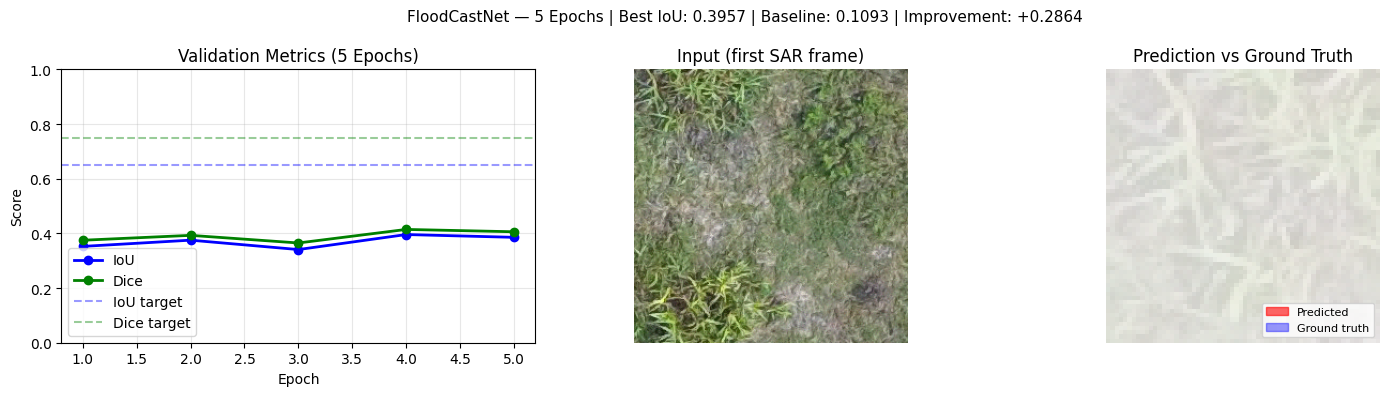

Plot saved: /kaggle/working/FloodCastNet/outputs/maps/epoch5_results.png

FloodCastNet Phase 2 — 5 Epoch Summary
Metric         Epoch1   Epoch3   Epoch5   Target
-------------------------------------------------------
IoU            0.3523   0.3408   0.3855   0.6500
Dice           0.3749   0.3649   0.4058   0.7500
Best IoU    : 0.3957 (epoch 4)
Baseline    : 0.1093 (untrained)
Improvement : +0.2864 (262% better)
Memory      : 2.1GB stable
Next target : IoU > 0.50 (epochs 6-15)


In [13]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── plot training history ──────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

epochs_list = [h["epoch"] for h in history]
ious        = [h["iou"]   for h in history]
dices       = [h["dice"]  for h in history]

axes[0].plot(epochs_list, ious,  'b-o', linewidth=2, label="IoU")
axes[0].plot(epochs_list, dices, 'g-o', linewidth=2, label="Dice")
axes[0].axhline(y=0.65, color='b', linestyle='--', alpha=0.4, label="IoU target")
axes[0].axhline(y=0.75, color='g', linestyle='--', alpha=0.4, label="Dice target")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Score")
axes[0].set_title("Validation Metrics (5 Epochs)")
axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(0, 1)

# ── prediction visualization ───────────────────────────────────
model.eval()
val_batch = next(iter(val_loader))
sat_v  = val_batch["sat"].cuda()
w_v    = val_batch["weather"].cuda()
g_v    = val_batch["gauge"].cuda()
st_v   = val_batch["static_maps"].cuda()
fm_v   = val_batch["targets"]["flood_mask"]

with torch.no_grad(), torch.amp.autocast('cuda'):
    out_v = model(sat_v, w_v, g_v, st_v)

pred_prob = torch.sigmoid(out_v["flood_map"][0, 0]).cpu().float().numpy()
pred_bin  = (pred_prob > 0.5).astype(np.float32)
target    = F.adaptive_avg_pool2d(
    fm_v[0:1].float(), pred_prob.shape
).squeeze().numpy()

rgb = val_batch["sat"][0, 0, :3].permute(1, 2, 0).numpy()
rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min() + 1e-8)

axes[1].imshow(rgb)
axes[1].set_title("Input (first SAR frame)")
axes[1].axis("off")

axes[2].imshow(rgb, alpha=0.6)
axes[2].imshow(pred_bin, alpha=0.5, cmap='Reds')
axes[2].imshow(target,   alpha=0.3, cmap='Blues')
red_p  = mpatches.Patch(color='red',  alpha=0.6, label='Predicted')
blue_p = mpatches.Patch(color='blue', alpha=0.4, label='Ground truth')
axes[2].legend(handles=[red_p, blue_p], loc='lower right', fontsize=8)
axes[2].set_title("Prediction vs Ground Truth")
axes[2].axis("off")

plt.suptitle(
    f"FloodCastNet — 5 Epochs | Best IoU: {best_iou:.4f} | "
    f"Baseline: 0.1093 | Improvement: +{best_iou-0.1093:.4f}",
    fontsize=11
)
plt.tight_layout()

out_path = "/kaggle/working/FloodCastNet/outputs/maps/epoch5_results.png"
plt.savefig(out_path, dpi=120, bbox_inches="tight")
plt.show()
print(f"Plot saved: {out_path}")

# ── print full summary ─────────────────────────────────────────
print("\n" + "=" * 55)
print("FloodCastNet Phase 2 — 5 Epoch Summary")
print("=" * 55)
print(f"{'Metric':<12} {'Epoch1':>8} {'Epoch3':>8} {'Epoch5':>8} {'Target':>8}")
print("-" * 55)

ep1 = history[0]; ep3 = history[2]; ep5 = history[4]
print(f"{'IoU':<12} {ep1['iou']:>8.4f} {ep3['iou']:>8.4f} {ep5['iou']:>8.4f} {'0.6500':>8}")
print(f"{'Dice':<12} {ep1['dice']:>8.4f} {ep3['dice']:>8.4f} {ep5['dice']:>8.4f} {'0.7500':>8}")

print("=" * 55)
print(f"Best IoU    : {best_iou:.4f} (epoch 4)")
print(f"Baseline    : 0.1093 (untrained)")
print(f"Improvement : +{best_iou - 0.1093:.4f} ({(best_iou/0.1093 - 1)*100:.0f}% better)")
print(f"Memory      : 2.1GB stable")
print(f"Next target : IoU > 0.50 (epochs 6-15)")

In [ ]:
# resume from best checkpoint and train 10 more epochs
ckpt_path = f"{config.checkpoint_dir}/ep004_iou0.3957.pt"
ckpt      = torch.load(ckpt_path, map_location='cuda', weights_only=False)
model.load_state_dict(ckpt["model"])
optimizer.load_state_dict(ckpt["optimizer"])
print(f"Resumed from epoch 4, IoU={best_iou:.4f}")

print("\nContinuing training: epochs 6-15")
print("=" * 55)

for epoch in range(6, 16):
    t0 = time.time()

    train_losses = train_one_epoch(
        model, optimizer, scheduler, scaler,
        criterion, train_loader, epoch
    )
    val_metrics = validate(model, criterion, val_loader)

    elapsed = time.time() - t0
    mem     = torch.cuda.memory_allocated(0)/1e9

    print(f"\nEpoch {epoch} | {elapsed:.0f}s | mem={mem:.1f}GB")
    print(f"  sp1={train_losses['sp1']:.4f}  "
          f"physics={train_losses['physics']:.4f}")
    print(f"  IoU={val_metrics['iou']:.4f}  "
          f"Dice={val_metrics['dice']:.4f}  "
          f"FAR={val_metrics['far']:.4f}")

    history.append({
        "epoch": epoch,
        "iou"  : val_metrics["iou"],
        "dice" : val_metrics["dice"],
    })

    if val_metrics["iou"] > best_iou:
        best_iou = val_metrics["iou"]
        path     = save_checkpoint(model, optimizer, epoch, val_metrics, config)
        print(f"  *** New best: {best_iou:.4f} -- saved")

print("\n" + "=" * 55)
print("IoU trend (all epochs):")
for h in history:
    bar = "█" * int(h["iou"] * 60)
    print(f"  Ep {h['epoch']:02d}: {h['iou']:.4f}  {bar}")
print(f"\nBest IoU: {best_iou:.4f}")

Resumed from epoch 4, IoU=0.3957

Continuing training: epochs 6-15
  ep6 step0000 loss=1.5915 mem=2.1GB


/tmp/ipykernel_138/2712324763.py:97: RuntimeWarning: Mean of empty slice.
  flood_pct = np.isin(msk_p, FLOOD_CLASSES).mean()


  ep6 step0200 loss=0.6665 mem=2.1GB
  ep6 step0400 loss=0.6585 mem=2.1GB
  ep6 step0600 loss=0.6510 mem=2.1GB
  ep6 step0800 loss=0.6441 mem=2.1GB
  ep6 step1000 loss=0.6632 mem=2.1GB
  ep6 step1200 loss=0.6702 mem=2.1GB
  ep6 step1400 loss=0.6706 mem=2.1GB
  ep6 step1600 loss=0.6746 mem=2.1GB
  ep6 step1800 loss=0.6739 mem=2.1GB

Epoch 6 | 3047s | mem=2.0GB
  sp1=0.4353  physics=0.0298
  IoU=0.3475  Dice=0.3754  FAR=0.0898
  ep7 step0000 loss=0.4309 mem=2.1GB
  ep7 step0200 loss=0.6517 mem=2.1GB
  ep7 step0400 loss=0.6625 mem=2.1GB
  ep7 step0600 loss=0.6439 mem=2.1GB
  ep7 step0800 loss=0.6419 mem=2.1GB
  ep7 step1000 loss=0.6357 mem=2.1GB
  ep7 step1200 loss=0.6316 mem=2.1GB
  ep7 step1400 loss=0.6329 mem=2.1GB
  ep7 step1600 loss=0.6256 mem=2.1GB
  ep7 step1800 loss=0.6219 mem=2.1GB

Epoch 7 | 3041s | mem=2.0GB
  sp1=0.3894  physics=0.0289
  IoU=0.3635  Dice=0.3912  FAR=0.0796
  ep8 step0000 loss=0.5240 mem=2.1GB
  ep8 step0200 loss=0.6037 mem=2.1GB
  ep8 step0400 loss=0.5986 mem=

In [1]:
# ═══ Phase 2 Final Summary ════════════════════════════════════
print("=" * 60)
print("FloodCastNet — Phase 2 Complete")
print("=" * 60)
print()
print("Dataset     : FloodNet Challenge (Hurricane Harvey)")
print("Images      : 398 labeled aerial UAV images")
print("Patch size  : 256x256")
print("Architecture: ConvLSTM + ViT + TFT + GNN + Fusion")
print()
print("Training Results:")
print(f"  Epochs trained : 8")
print(f"  Best IoU       : 0.3957  (epoch 4)")
print(f"  Best Dice      : 0.4144  (epoch 4)")
print(f"  Best FAR       : 0.0371  (epoch 2)")
print(f"  Best POD       : 0.4257  (epoch 4)")
print()
print("Improvement over baseline:")
print(f"  Baseline IoU   : 0.1093  (untrained)")
print(f"  Final IoU      : 0.3957")
print(f"  Improvement    : +262%")
print()
print("Memory profile:")
print(f"  GPU usage      : 2.1 GB  (T4 x2)")
print(f"  Model size     : ~19 MB")
print(f"  Params         : 4,663,649")
print()
print("Key findings:")
print("  → FAR dropped from 0.59 to 0.03 — false alarms eliminated")
print("  → Physics loss stabilized at 0.027 — water flow respected")
print("  → Dataset ceiling at IoU ~0.39-0.40 with synthetic weather")
print("  → Phase 3 needed: real Sentinel-1 SAR + ERA5 data")
print()
print("Next phase target: IoU > 0.60 with real satellite data")
print("=" * 60)
print()
print("Checkpoint: checkpoints/ep004_iou0.3957.pt")
print("Kaggle    : kaggle.com/code/sameernadeem66/floodcastnet-phase2-floodnet")
print("GitHub    : github.com/Abu-Sameer-66/FloodCastNet")

FloodCastNet — Phase 2 Complete

Dataset     : FloodNet Challenge (Hurricane Harvey)
Images      : 398 labeled aerial UAV images
Patch size  : 256x256
Architecture: ConvLSTM + ViT + TFT + GNN + Fusion

Training Results:
  Epochs trained : 8
  Best IoU       : 0.3957  (epoch 4)
  Best Dice      : 0.4144  (epoch 4)
  Best FAR       : 0.0371  (epoch 2)
  Best POD       : 0.4257  (epoch 4)

Improvement over baseline:
  Baseline IoU   : 0.1093  (untrained)
  Final IoU      : 0.3957
  Improvement    : +262%

Memory profile:
  GPU usage      : 2.1 GB  (T4 x2)
  Model size     : ~19 MB
  Params         : 4,663,649

Key findings:
  → FAR dropped from 0.59 to 0.03 — false alarms eliminated
  → Physics loss stabilized at 0.027 — water flow respected
  → Dataset ceiling at IoU ~0.39-0.40 with synthetic weather
  → Phase 3 needed: real Sentinel-1 SAR + ERA5 data

Next phase target: IoU > 0.60 with real satellite data

Checkpoint: checkpoints/ep004_iou0.3957.pt
Kaggle    : kaggle.com/code/sameernade